# Исследование объявлений о продаже квартир

## Описание проекта

В нашем распоряжении данные сервиса Яндекс Недвижимость — архив объявлений о продаже квартир в Санкт-Петербурге и соседних населённых пунктах за несколько лет. Нам нужно научиться определять рыночную стоимость объектов недвижимости. Для этого проведем исследовательский анализ данных и установим параметры, влияющие на цену объектов. Это позволит построить автоматизированную систему: она отследит аномалии и мошенническую деятельность.

## Описание данных

По каждой квартире на продажу доступны два вида данных. Первые вписаны пользователем, вторые — получены автоматически на основе картографических данных. Например, расстояние до центра, аэропорта и других объектов — эти данные автоматически получены из геосервисов. Количество парков и водоёмов также заполняется без участия пользователя.

Данные хранятся в датасете real_estate_data.csv

- airports_nearest — расстояние до ближайшего аэропорта в метрах (м)
- balcony — число балконов
- ceiling_height — высота потолков (м)
- cityCenters_nearest — расстояние до центра города (м)
- days_exposition — сколько дней было размещено объявление (от публикации до снятия)
- first_day_exposition — дата публикации
- floor — этаж
- floors_total — всего этажей в доме
- is_apartment — апартаменты (булев тип)
- kitchen_area — площадь кухни в квадратных метрах (м²)
- last_price — цена на момент снятия с публикации
- living_area — жилая площадь в квадратных метрах (м²)
- locality_name — название населённого пункта
- open_plan — свободная планировка (булев тип)
- parks_around3000 — число парков в радиусе 3 км
- parks_nearest — расстояние до ближайшего парка (м)
- ponds_around3000 — число водоёмов в радиусе 3 км
- ponds_nearest — расстояние до ближайшего водоёма (м)
- rooms — число комнат
- studio — квартира-студия (булев тип)
- total_area — общая площадь квартиры в квадратных метрах (м²)
- total_images — число фотографий квартиры в объявлении

## План исследования
**Шаг 1.** Откроем файл с данными и изучим общую информацию

Путь к файлу: /datasets/real_estate_data.csv

- Загрузим данные из csv-файла в датафрейм c помощью библиотеки pandas.
- Изучим общую информацию о полученном датафрейме.
- Построим гистограмму для всех числовых столбцов таблицы на одном графике. 

**Шаг 2.** Выполним предобработку данных
- Найдем и изучим пропущенные значения в столбцах:
  - Определим, в каких столбцах есть пропуски.
  - Заполним пропущенные значения там, где это возможно. Например, если продавец не указал число балконов, то, скорее всего, в его квартире их нет. Такие пропуски можно заменить на число 0. Если логичную замену предложить невозможно, то оставим пропуски. Пропущенные значения — тоже важный сигнал, который нужно учитывать.
  - В ячейке с типом markdown укажем причины, которые могли привести к пропускам в данных.
- Рассмотрим типы данных в каждом столбце:
  - Найдем столбцы, в которых нужно изменить тип данных.
  - Преобразуем тип данных в выбранных столбцах.
  - В ячейке с типом markdown поясним, почему нужно изменить тип данных.
- Изучим уникальные значения в столбце с названиями и устраним неявные дубликаты. Например, «поселок Рябово» и «поселок городского типа Рябово», «поселок Тельмана» и «посёлок Тельмана» — это обозначения одних и тех же населённых пунктов. 

**Шаг 3.** Добавим в таблицу новые столбцы со следующими параметрами:
- цена одного квадратного метра (нужно поделить стоимость объекта на его общую площадь, а затем округлить до двух знаков после запятой);
- день недели публикации объявления (0 — понедельник, 1 — вторник и так далее);
- месяц публикации объявления;
- год публикации объявления;
- тип этажа квартиры (значения — «‎первый», «последний», «другой»);
- расстояние до центра города в километрах (переведем из м в км и округлим до ближайших целых значений).

**Шаг 4.** Проведем исследовательский анализ данных:
- Изучим перечисленные ниже параметры объектов и построим отдельные гистограммы для каждого из этих параметров. В некоторых параметрах встречаются редкие и выбивающиеся значения. При построении гистограмм удалим их. Например, в столбце ceiling_height может быть указана высота потолков 25 м и 32 м. Логично предположить, что на самом деле это вещественные значения: 2.5 м и 3.2 м. Попробуем обработать аномалии в этом и других столбцах, если они есть. Если природа аномалии понятна и данные действительно искажены, то восстановим корректное значение. В противном случае удалим редкие и выбивающиеся значения.
- Список параметров:
  - общая площадь;
  - жилая площадь;
  - площадь кухни;
  - цена объекта;
  - количество комнат;
  - высота потолков;
  - тип этажа квартиры («первый», «последний», «другой»);
  - общее количество этажей в доме;
  - расстояние до центра города в метрах;
  - расстояние до ближайшего парка
- Опишем все наши наблюдения по параметрам.
- Изучим, как быстро продавались квартиры (столбец days_exposition). Этот параметр показывает, сколько дней было размещено каждое объявление.
- Построим гистограмму.
- Посчитаем среднее и медиану.
- Опишем, сколько времени обычно занимает продажа. Какие продажи можно считать быстрыми, а какие — необычно долгими
- Определим факторы, которые больше всего влияют на общую (полную) стоимость объекта.
- Изучим, зависит ли цена от:
  - общей площади;
  - жилой площади;
  - площади кухни;
  - количества комнат;
  - этажа, на котором расположена квартира (первый, последний, другой);
  - даты размещения (день недели, месяц, год).
- Построим графики, которые покажут зависимость цены от указанных выше параметров.
- Посчитаем среднюю цену одного квадратного метра в 10 населённых пунктах с наибольшим числом объявлений — построим сводную таблицу с количеством объявлений и средней ценой квадратного метра для этих населенных пунктов. Выделим населённые пункты с самой высокой и низкой стоимостью квадратного метра.
- Ранее мы посчитали расстояние до центра в километрах. Теперь выделим квартиры в Санкт-Петербурге с помощью столбца locality_name и вычислим их среднюю стоимость на разном удалении от центра. Учтем каждый километр расстояния: узнаем среднюю цену квартир в одном километре от центра, в двух и так далее. Опишем, как стоимость объектов зависит от расстояния до центра города — построим график изменения средней цены для каждого километра от центра Петербурга.

**Шаг 5.** Напишем общий вывод
- Опишем полученные результаты и зафиксируем итоговый вывод проведённого исследования.


In [1]:
#импортируем библиотеки
import pandas as pd
import datetime as dt
import seaborn
#импортируем нужную библиотеку для изменения размера диаграммы по осям
import matplotlib.pyplot as plt

### Откроем файл с данными и изучим общую информацию

In [2]:
#открываем файл формата CSV нужным методом из библиотеки pandas
data = pd.read_csv("/datasets/real_estate_data.csv", sep="\t")
#выводим первые пять строк
data.head()

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.0,2019-03-07T00:00:00,3,2.70,16.0,51.0,8,NaN,...,25.0,NaN,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.4,2018-12-04T00:00:00,1,NaN,11.0,18.6,1,NaN,...,11.0,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.0,2015-08-20T00:00:00,2,NaN,5.0,34.3,4,NaN,...,8.3,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.0,2015-07-24T00:00:00,3,NaN,14.0,NaN,9,NaN,...,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.0,2018-06-19T00:00:00,2,3.03,14.0,32.0,13,NaN,...,41.0,NaN,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0


In [3]:
#выводим общую информацию
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23699 non-null  int64  
 1   last_price            23699 non-null  float64
 2   total_area            23699 non-null  float64
 3   first_day_exposition  23699 non-null  object 
 4   rooms                 23699 non-null  int64  
 5   ceiling_height        14504 non-null  float64
 6   floors_total          23613 non-null  float64
 7   living_area           21796 non-null  float64
 8   floor                 23699 non-null  int64  
 9   is_apartment          2775 non-null   object 
 10  studio                23699 non-null  bool   
 11  open_plan             23699 non-null  bool   
 12  kitchen_area          21421 non-null  float64
 13  balcony               12180 non-null  float64
 14  locality_name         23650 non-null  object 
 15  airports_nearest   

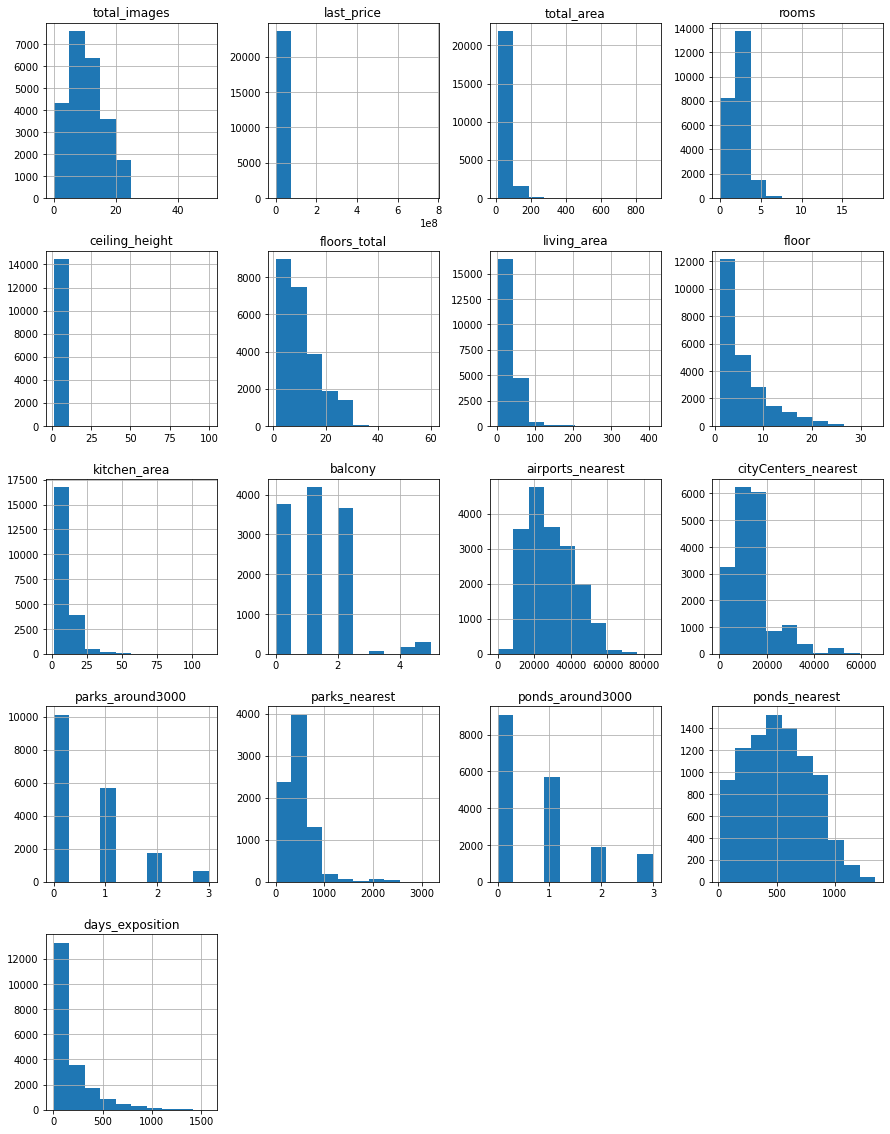

In [4]:
#Построим гистограмму для всех числовых столбцов таблицы на одном графике. 
data.hist(figsize=(15, 20));

ВЫВОД: На этапе знакомства с данными, можно заметить: во многих столбцах присутствуют пропуски(в некоторых они составляют менее 1% от общего числа, а в других более 70%). Также вызывают сомнения типы данных некоторых столбцов(например в столбце с датой публикации "first_day_exposition" тип данных object, хотя хранящиеся данные явно должны быть переведены в даты). В процессе более детального просмотра данных мы сможем убрать пропуски там, где это требуется, а также исправить тип данных(где есть в этом необходимость) 

### Выполним предобработку данных

**Изучим данные поподробнее: рассмотрим каждый столбец по отдельности, просмотрим пропущенные значения для столбцов, дубликаты, аномальные значения**

In [5]:
#Выводим количество пропущенных значений для каждого столбца
data.isna().sum()

total_images                0
last_price                  0
total_area                  0
first_day_exposition        0
rooms                       0
ceiling_height           9195
floors_total               86
living_area              1903
floor                       0
is_apartment            20924
studio                      0
open_plan                   0
kitchen_area             2278
balcony                 11519
locality_name              49
airports_nearest         5542
cityCenters_nearest      5519
parks_around3000         5518
parks_nearest           15620
ponds_around3000         5518
ponds_nearest           14589
days_exposition          3181
dtype: int64

Теперь видны столбцы, которые содержат пропуски. Изучим каждый далее и обработаем пропуски.

In [6]:
#Посмотрим наличие явных дубликатов:
data.duplicated().sum()

0

Наличие явных дубликатов не установлено. При просмотре столбцов, проверим: возможно присутствуют неявные.

**1) СТОЛБЦЫ floors_total и locality_name**

Изучим полученные данные по пропускам: В столбце floors_total всего 86 пропусков, это примерно 0,4% от всех данных этого столбца. Тем более у нас нет возможности заполнить эти пропуски(непонятно, какие вставленные значения не окажут негативное воздействие на результаты исследования, т.к. могут искажать данные). Такая же ситуация и со столбцом locality_name пропуски составляют 0,2%. Пропуски появились в этих столбцах скорее всего потому что пользователи не указали эти данные.
Можем их удалить без потери качества данных

In [7]:
#избавимся от пропусков в столбце floors_total и в locality_name
data= data.dropna(subset=["floors_total", "locality_name"])
#для проверки выведем количество пропущенных значений для каждого столбца
data.isna().sum()

total_images                0
last_price                  0
total_area                  0
first_day_exposition        0
rooms                       0
ceiling_height           9084
floors_total                0
living_area              1865
floor                       0
is_apartment            20805
studio                      0
open_plan                   0
kitchen_area             2222
balcony                 11475
locality_name               0
airports_nearest         5524
cityCenters_nearest      5501
parks_around3000         5500
parks_nearest           15535
ponds_around3000         5500
ponds_nearest           14529
days_exposition          3171
dtype: int64

**ДУБЛИКАТЫ В СТОЛБЦЕ locality_name**

Рассмотрим столбец  locality_name: проверим на наличие неявных дубликатов

In [8]:
#выводим уникальные значения: 
data["locality_name"].unique()

array(['Санкт-Петербург', 'посёлок Шушары', 'городской посёлок Янино-1',
       'посёлок Парголово', 'посёлок Мурино', 'Ломоносов', 'Сертолово',
       'Петергоф', 'Пушкин', 'деревня Кудрово', 'Коммунар', 'Колпино',
       'поселок городского типа Красный Бор', 'Гатчина', 'поселок Мурино',
       'деревня Фёдоровское', 'Выборг', 'Кронштадт', 'Кировск',
       'деревня Новое Девяткино', 'посёлок Металлострой',
       'посёлок городского типа Лебяжье',
       'посёлок городского типа Сиверский', 'поселок Молодцово',
       'поселок городского типа Кузьмоловский',
       'садовое товарищество Новая Ропша', 'Павловск',
       'деревня Пикколово', 'Всеволожск', 'Волхов', 'Кингисепп',
       'Приозерск', 'Сестрорецк', 'деревня Куттузи', 'посёлок Аннино',
       'поселок городского типа Ефимовский', 'посёлок Плодовое',
       'деревня Заклинье', 'поселок Торковичи', 'поселок Первомайское',
       'Красное Село', 'посёлок Понтонный', 'Сясьстрой', 'деревня Старая',
       'деревня Лесколово', '

Названия населенных пунктов - это всё дубликаты, которые можно заменить на "поселок"(аналогично и с посЁлок)

In [9]:
#Избавимся от дубликатов
data['locality_name'] = (
    data['locality_name']
    .str.replace('ё', 'е')
    .str.replace(r'(садоводческое некоммерческое товарищество|коттеджный поселок|городской поселок|поселок городского типа|садовое товарищество|село|деревня)\b', 'поселок', regex=True)
)
#проверим, выведем уникальные значения

data["locality_name"].unique()

array(['Санкт-Петербург', 'поселок Шушары', 'поселок Янино-1',
       'поселок Парголово', 'поселок Мурино', 'Ломоносов', 'Сертолово',
       'Петергоф', 'Пушкин', 'поселок Кудрово', 'Коммунар', 'Колпино',
       'поселок Красный Бор', 'Гатчина', 'поселок Федоровское', 'Выборг',
       'Кронштадт', 'Кировск', 'поселок Новое Девяткино',
       'поселок Металлострой', 'поселок Лебяжье', 'поселок Сиверский',
       'поселок Молодцово', 'поселок Кузьмоловский',
       'поселок Новая Ропша', 'Павловск', 'поселок Пикколово',
       'Всеволожск', 'Волхов', 'Кингисепп', 'Приозерск', 'Сестрорецк',
       'поселок Куттузи', 'поселок Аннино', 'поселок Ефимовский',
       'поселок Плодовое', 'поселок Заклинье', 'поселок Торковичи',
       'поселок Первомайское', 'Красное Село', 'поселок Понтонный',
       'Сясьстрой', 'поселок Старая', 'поселок Лесколово',
       'поселок Новый Свет', 'Сланцы', 'поселок Путилово', 'Ивангород',
       'Мурино', 'Шлиссельбург', 'Никольское', 'Зеленогорск',
       'С

**2) СТОЛБЕЦ balcony**

Пропуски в столбце balcony логически можно заменить на 0, так как скорее всего данные не указаны, потому что балкона нет

In [10]:
#заменим пропуски на 0
data['balcony'] = data['balcony'].fillna(0)

Данные в этом столбце не могут быть вещественными(напр. 1.5 - странное наличие балкона :)
Поэтому поменяем тип данных на целочисленный:

In [11]:
#поменяем тип данных в столбце balcony
data["balcony"] = data["balcony"].astype(int)

**3) СТОЛБЦЫ  cityCenters_nearest, ponds_nearest, parks_nearest, airports_nearest**

Данные в столбцах cityCenters_nearest, ponds_nearest, parks_nearest, airports_nearest похожи, они показывают расстояние до ближайшего нужного места. Так как эти данные автоматически получены из геосервисов, возможно при выгрузке произошла ошибка. НО  так как размах выборки большой, заполнение пропусков может привести к тому, что данные окажутся неактуальными - стоит оставить пропуски без изменений.

In [12]:
data.isna().sum()

total_images                0
last_price                  0
total_area                  0
first_day_exposition        0
rooms                       0
ceiling_height           9084
floors_total                0
living_area              1865
floor                       0
is_apartment            20805
studio                      0
open_plan                   0
kitchen_area             2222
balcony                     0
locality_name               0
airports_nearest         5524
cityCenters_nearest      5501
parks_around3000         5500
parks_nearest           15535
ponds_around3000         5500
ponds_nearest           14529
days_exposition          3171
dtype: int64

**4) СТОЛБЕЦ ceiling_height**

В столбце ceiling_height пропущенные значения можно обьяснить тем, что высоту потолка редко указывают 
Их можно заменить пока медианой:

In [13]:
#найдем медиану и запишем ее в переменную median_ceiling
median_ceiling = data['ceiling_height'].median()
#заменим пропуски этим медианным значением
data['ceiling_height'].fillna(median_ceiling, inplace=True)
#для проверки выведем количество пропусков
data['ceiling_height'].isna().sum()

0

**5) СТОЛБЦЫ ponds_around3000 и parks_around3000**

В столбце ponds_around3000 заменим на 0, так как скорее всего значения пропущены, потому что водоемов в радиусе 3км нет или так как данная информация получена автоматически, могли возникнуть технические проблемы при выгрузке данных**

Для начала посмотрим есть ли какая-то взаимосвязь между расположением пропусков в этих двух столбцах

In [14]:
#сохраним в отдельные переменные пустые значения по каждому из этих столбцов
ponds = data['ponds_around3000'].isna()
parks = data['parks_around3000'].isna()
#выведем корреляцию
ponds.corr(parks)

0.9999999999999999

Так как взаимосвязь присутствует, это означает что замена пропусков будет идентичная. Пока не будем трогать пропуски и менять тип данных в этих столбцах

**6) СТОЛБЕЦ days_exposition**

По столбцу days_exposition - Мы можем заполнять только те данные, которые пропущенны совершенно случайно. Иначе заполнение может повлиять на характер связи между заполняемой величиной и остальными. Попробуем рассмотреть распределение пропусков в данном столбце относительно года выставления квартиры на продажу.

In [15]:
data['first_day_exposition'] = pd.to_datetime(data['first_day_exposition'], format='%Y-%m-%dT%H:%M:%S')
data['first_day_year'] = data['first_day_exposition'].dt.year
data[data['days_exposition'].isnull()].pivot_table(columns = 'first_day_year', values = 'total_area', aggfunc = 'count')

first_day_year,2014,2015,2016,2017,2018,2019
total_area,18,70,67,271,957,1788


Если рассматривать распределение пропусков относительно года выставления на продажу, можно заметить, что большая часть пропущенных значений - в 2019 году. Больше половины объектов, выставленных на продажу в 2019 году не имеет рассчитанного "времени продажи квартиры". Также высокая доля пропусков, хотя и меньшая - в 2018 году. Получается, чем свежей объявление - тем выше вероятность пропуска в этой колонке.

Пропуск в этой колонке означает, что объект не продан и объявление не закрыто. Поэтому заполнять пропуски в этом столбце не надо - они не случайные и существенно влияют на статистику.

**7) Рассмотрим столбец is_apartment:**

пропусков много(20805, что составляет 88% от общего числа данных). Так как эти данные мы получили от пользователя, вполне вероятно, что пропуски означают отсутствие такого вида жилья. Лучше заменить их на наиболее распросраненное значение в этом столбце

In [16]:
#выводим описание столбца с помощью ф-ции describe()
print(data["is_apartment"].describe())

count      2760
unique        2
top       False
freq       2710
Name: is_apartment, dtype: object


In [17]:
#наиболее распространенное значение -- False, заменим пропуски им:
apartment_mode=data["is_apartment"].mode()[0]
data["is_apartment"].fillna(apartment_mode, inplace=True)
#для проверки проверим наличие пропусков в столбце:
data["is_apartment"].isna().sum()

0

Отлично, пропусков нет.

Так как эти данные должны быть булевого типа, поменяем тип данных на bool

In [18]:
data["is_apartment"].astype(bool)

0        False
1        False
2        False
3        False
4        False
         ...  
23694    False
23695    False
23696    False
23697    False
23698    False
Name: is_apartment, Length: 23565, dtype: bool

**8) В столбцах living_area и  kitchen_area пропуски можно обьяснить: скорее всего люди просто общую площадь указывают, а по отдельности нет. Посмотрим на наличие зависимости между общей и жилой площадью/площадью кухни:**


In [19]:
print(data['living_area'].corr(data['total_area']))

0.9397711143610334


Жилая площадь очень сильно коррелирует с общей(коэффицент Пирсона равен ~0.94, что говорит о наличии сильной связи между ними)

In [20]:
print(data['kitchen_area'].corr(data['total_area']))

0.6092476784548312


Аналогично и с площадью кухни, хоть тут коэффицент корреляции и меньше, значит связь слабее

Значит данные в этих столбцах можно восстановить с помощью общей площади:

In [21]:
#найдем отношение жилой площади к общей
dispos_living_area = data["living_area"]/ data["total_area"]
#возьмем средний коэффициент отношения
dispos_living_area.mean()

0.5649371748241468

In [22]:
#заменим пропуски
data["living_area"] = data['living_area'].fillna(data["total_area"]*dispos_living_area.mean())
#для проверки выведем первые 10 строк
data["living_area"].head(10)

0    51.000000
1    18.600000
2    34.300000
3    89.825011
4    32.000000
5    14.400000
6    10.600000
7    40.449502
8    15.430000
9    43.600000
Name: living_area, dtype: float64

In [23]:
#найдем отношение площади кухни к общей
dispos_kitchen_area = data["kitchen_area"]/ data["total_area"]
#возьмем средний коэффициент отношения
dispos_kitchen_area.mean()

0.18733959855294968

In [24]:
#заменим пропуски
data["kitchen_area"] = data['kitchen_area'].fillna(data["total_area"]*dispos_kitchen_area.mean())
#для проверки выведем первые 10 строк
data["kitchen_area"].head(10)

0    25.000000
1    11.000000
2     8.300000
3    29.786996
4    41.000000
5     9.100000
6    14.400000
7    18.900000
8     8.810000
9     6.500000
Name: kitchen_area, dtype: float64

In [25]:
data.isna().sum()

total_images                0
last_price                  0
total_area                  0
first_day_exposition        0
rooms                       0
ceiling_height              0
floors_total                0
living_area                 0
floor                       0
is_apartment                0
studio                      0
open_plan                   0
kitchen_area                0
balcony                     0
locality_name               0
airports_nearest         5524
cityCenters_nearest      5501
parks_around3000         5500
parks_nearest           15535
ponds_around3000         5500
ponds_nearest           14529
days_exposition          3171
first_day_year              0
dtype: int64

**Посмотрим на типы данных в других стобцах:**
- в столбце "first_day_exposition" должен быть формат времени.
Исправим это: 

In [26]:
#поменяем тип данных:
data["first_day_exposition"]= pd.to_datetime(data["first_day_exposition"], format="%Y-%m-%dT%H:%M:%S")
#для проверки выводим общую инфу:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 23565 entries, 0 to 23698
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   total_images          23565 non-null  int64         
 1   last_price            23565 non-null  float64       
 2   total_area            23565 non-null  float64       
 3   first_day_exposition  23565 non-null  datetime64[ns]
 4   rooms                 23565 non-null  int64         
 5   ceiling_height        23565 non-null  float64       
 6   floors_total          23565 non-null  float64       
 7   living_area           23565 non-null  float64       
 8   floor                 23565 non-null  int64         
 9   is_apartment          23565 non-null  bool          
 10  studio                23565 non-null  bool          
 11  open_plan             23565 non-null  bool          
 12  kitchen_area          23565 non-null  float64       
 13  balcony         

- Заменим в столбцах, где это возможно, тип данных float64 на int64:

In [27]:
#для удобства снова выведем первые 10 строк таблицы:
data.head(10)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,first_day_year
0,20,13000000.0,108.00,2019-03-07,3,2.70,16.0,51.000000,8,False,...,0,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN,2019
1,7,3350000.0,40.40,2018-12-04,1,2.65,11.0,18.600000,1,False,...,2,поселок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0,2018
2,10,5196000.0,56.00,2015-08-20,2,2.65,5.0,34.300000,4,False,...,0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0,2015
3,0,64900000.0,159.00,2015-07-24,3,2.65,14.0,89.825011,9,False,...,0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0,2015
4,2,10000000.0,100.00,2018-06-19,2,3.03,14.0,32.000000,13,False,...,0,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0,2018
5,10,2890000.0,30.40,2018-09-10,1,2.65,12.0,14.400000,5,False,...,0,поселок Янино-1,NaN,NaN,NaN,NaN,NaN,NaN,55.0,2018
6,6,3700000.0,37.30,2017-11-02,1,2.65,26.0,10.600000,6,False,...,1,поселок Парголово,52996.0,19143.0,0.0,NaN,0.0,NaN,155.0,2017
7,5,7915000.0,71.60,2019-04-18,2,2.65,24.0,40.449502,22,False,...,2,Санкт-Петербург,23982.0,11634.0,0.0,NaN,0.0,NaN,NaN,2019
8,20,2900000.0,33.16,2018-05-23,1,2.65,27.0,15.430000,26,False,...,0,поселок Мурино,NaN,NaN,NaN,NaN,NaN,NaN,189.0,2018
9,18,5400000.0,61.00,2017-02-26,3,2.50,9.0,43.600000,7,False,...,2,Санкт-Петербург,50898.0,15008.0,0.0,NaN,0.0,NaN,289.0,2017


По логике в столбце total_images не могут быть вещественные данные(фотографий не может быть например 1.5 шт) , поэтому можно поменять тип на int

In [28]:
data["total_images"].astype(int)

0        20
1         7
2        10
3         0
4         2
         ..
23694     9
23695    14
23696    18
23697    13
23698     4
Name: total_images, Length: 23565, dtype: int64

Сделаем то же и с другими подходящими столбцами(с теми, в которых значения хоть и записаны, как вещественные, но при этом можно отбросить дробну часть, так как это нули):

In [29]:
#поменяем типы данных в соответствующих столбцах:
data["last_price"] = data["last_price"].astype(int)
data["floors_total"] = data["floors_total"].astype(int)

In [30]:
#посмотрим на типы данных теперь: 
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 23565 entries, 0 to 23698
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   total_images          23565 non-null  int64         
 1   last_price            23565 non-null  int64         
 2   total_area            23565 non-null  float64       
 3   first_day_exposition  23565 non-null  datetime64[ns]
 4   rooms                 23565 non-null  int64         
 5   ceiling_height        23565 non-null  float64       
 6   floors_total          23565 non-null  int64         
 7   living_area           23565 non-null  float64       
 8   floor                 23565 non-null  int64         
 9   is_apartment          23565 non-null  bool          
 10  studio                23565 non-null  bool          
 11  open_plan             23565 non-null  bool          
 12  kitchen_area          23565 non-null  float64       
 13  balcony         

**ВЫВОД: Мы избавились от пропусков в столбцах, где это было возможно, от неявных дубликатов и поменяли типы данных. В таком виде данные пригодны для анализа. Но перед анализом нужно избавится от выбросов и аномалий в столбцах. Этим мы займемся далее. Но сначала надо внести дополнительную информацию.**

### Добавим новые признаки:

- Для начала найдем стоимость одного кв.метра 

In [31]:
data["price_sq_meter"] = data['last_price'] / data['total_area']
data["price_sq_meter"]

0        120370.370370
1         82920.792079
2         92785.714286
3        408176.100629
4        100000.000000
             ...      
23694     72490.845228
23695     52542.372881
23696     44091.710758
23697    149511.400651
23698     41795.665635
Name: price_sq_meter, Length: 23565, dtype: float64

- Извлечем дни недели из данных столбца first_day_exposition в столбец weekday

In [32]:
data['weekday'] = data['first_day_exposition'].dt.weekday
data['weekday']

0        3
1        1
2        3
3        4
4        1
        ..
23694    1
23695    0
23696    6
23697    1
23698    4
Name: weekday, Length: 23565, dtype: int64

- Теперь месяц публикации объявления:

In [33]:
data['month_of_publication'] = data['first_day_exposition'].dt.month
data['month_of_publication']

0         3
1        12
2         8
3         7
4         6
         ..
23694     3
23695     1
23696     2
23697     3
23698     7
Name: month_of_publication, Length: 23565, dtype: int64

- Также извлечем год публикации:

In [34]:
data['year_of_publication'] = data['first_day_exposition'].dt.year
data['year_of_publication']

0        2019
1        2018
2        2015
3        2015
4        2018
         ... 
23694    2017
23695    2018
23696    2018
23697    2017
23698    2017
Name: year_of_publication, Length: 23565, dtype: int64

- Добавим тип этажа квартиры

In [35]:
#создадим функцию с условием для перебора данных в столбце:
def type_for_floor(row):
    floor = row["floor"]
    total_floor = row["floors_total"]
    if floor == 1:
        return "первый"
    if floor == total_floor:
        return "последний"
    return "другой"
#создадим столбец и сохраним в него эти данные     

data["floor_type"] = data.apply(type_for_floor, axis=1)
#выведем первые 5 строк
data["floor_type"].head()

0    другой
1    первый
2    другой
3    другой
4    другой
Name: floor_type, dtype: object

- Найдем расстояние до центра города в километрах

In [36]:
#переведем метры в км:
data["center_km_nearest"] = data["cityCenters_nearest"] / 1000
#округлим до ближайшего целого
data["center_km_nearest"] = data["center_km_nearest"].round()
data["center_km_nearest"]

0        16.0
1        19.0
2        14.0
3         7.0
4         8.0
         ... 
23694     4.0
23695     NaN
23696     NaN
23697    10.0
23698     NaN
Name: center_km_nearest, Length: 23565, dtype: float64

ВЫВОД: Мы добавили новые параметры: стоимость одного кв. метра, день недели, месяц и год публикации по отдельности, тип этажа, растояние до центра города в км. -- получив необходимую информацию из столбцов. Они нам пригодятся далее.

### Проведем исследовательский анализ данных

**Рассмотрим поподробнее параметры:**
- общая площадь;
- жилая площадь;
- площадь кухни;
- цена объекта;
- количество комнат;
- высота потолков;
- тип этажа квартиры («первый», «последний», «другой»);
- общее количество этажей в доме;
- расстояние до центра города в метрах;
- расстояние до ближайшего парка

Перед началом сохраним исходное кол-во в отдельную переменную

In [37]:
data_orig = data.copy()
data_orig.shape

(23565, 29)

**1) Общая площадь.**

In [38]:
#вывод общей информации по числовым характеристикам выборки
data["total_area"].describe()

count    23565.000000
mean        60.322824
std         35.657060
min         12.000000
25%         40.000000
50%         52.000000
75%         69.700000
max        900.000000
Name: total_area, dtype: float64

Создадим гистограмму для этого столбца: 

<AxesSubplot:>

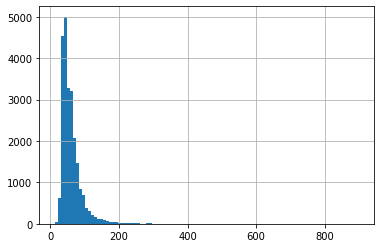

In [39]:
data["total_area"].hist(bins=100)

большая часть значений лежит в диапазоне до 200, что выглядит правдоподобно. 

<AxesSubplot:>

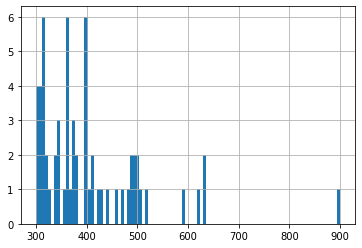

In [40]:
#сделаем гистограмму отдельно для значений больше 300
data["total_area"].hist(bins=100, range=(300,900))

здесь уже заметны слишком большие значения- выбросы

(-10.0, 400.0)

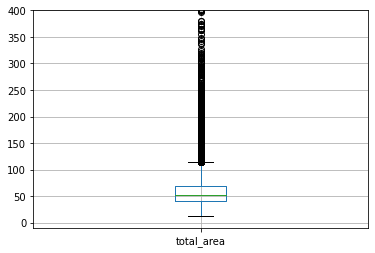

In [41]:
 #построим диаграмму размаха
data.boxplot("total_area")
#отделим нужный срез
plt.ylim(-10, 400)

Нижний «ус» чуть выше 0, минимальное значение. Верхний заканчивается около 115 — это 1,5 межквартильного размаха, добавленного к 3-му квартилю. Это ориентировочная граница нормального размаха. Всё, что лежит за ней, считается выбросом. В данных много слишком высоких значений: за пределами «усов» находятся выбросы. Они рисуются отдельными точками, но сливаются в единую жирную линию: таких выбросов очень много. По гистограмме видно, что отдельные значения присутствуют еще и на 900

Избавимся от выбросов, но при этом будем учитывать, что удаления слишком большого обьема данных может плохо сказаться на анализе в будущем, поэтому будем удалять не более 1% данных

In [42]:
#избавимся от выбросов, оставив только нужный срез данных: 
data= data.query("total_area <= 320")

In [43]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 23517 entries, 0 to 23698
Data columns (total 29 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   total_images          23517 non-null  int64         
 1   last_price            23517 non-null  int64         
 2   total_area            23517 non-null  float64       
 3   first_day_exposition  23517 non-null  datetime64[ns]
 4   rooms                 23517 non-null  int64         
 5   ceiling_height        23517 non-null  float64       
 6   floors_total          23517 non-null  int64         
 7   living_area           23517 non-null  float64       
 8   floor                 23517 non-null  int64         
 9   is_apartment          23517 non-null  bool          
 10  studio                23517 non-null  bool          
 11  open_plan             23517 non-null  bool          
 12  kitchen_area          23517 non-null  float64       
 13  balcony         

2) жилая площадь и площадь кухни

In [44]:
#вывод общей информации по числовым характеристикам выборки
data["living_area"].describe()

count    23517.000000
mean        34.139138
std         20.083780
min          2.000000
25%         19.000000
50%         30.000000
75%         42.000000
max        250.000000
Name: living_area, dtype: float64

<AxesSubplot:title={'center':'Жилая площадь'}, ylabel='Frequency'>

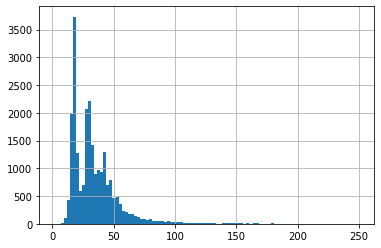

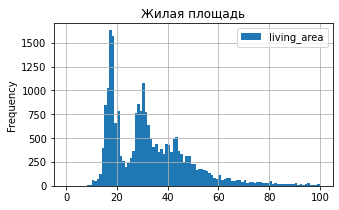

In [45]:
#построим гистограмму
data["living_area"].hist(bins=100)
data.plot(y = "living_area", kind="hist", title="Жилая площадь", bins=100, range=(0,100), grid=True, figsize=(5,3))

<AxesSubplot:>

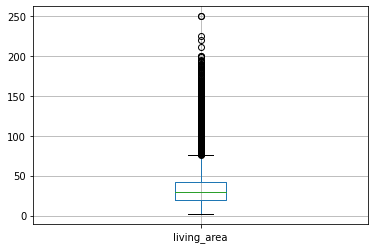

In [46]:
#построим диаграмму размаха
data.boxplot("living_area")

По гистограмме и диаграмме размаха видно, что значения, к-рые больше 70 -- это выбросы, но их количество малое, избавляться от них пока не будем

In [47]:
#вывод общей информации по числовым характеристикам выборки
data["kitchen_area"].describe()

count    23517.000000
mean        10.490440
std          5.760935
min          1.300000
25%          7.000000
50%          9.000000
75%         12.000000
max        107.000000
Name: kitchen_area, dtype: float64

<AxesSubplot:>

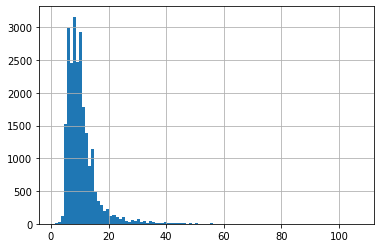

In [48]:
#построим гистограмму
data["kitchen_area"].hist(bins=100)

<AxesSubplot:>

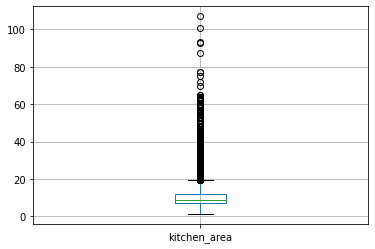

In [49]:
#построим диаграмму размаха
data.boxplot("kitchen_area")

Аналогично и с площадью кухни, тут выбросы от 20, но их также мало. Пока трогать не будем

4) цена объекта

In [50]:
#вывод общей информации по числовым характеристикам выборки
data["last_price"].describe()

count    2.351700e+04
mean     6.336494e+06
std      7.999596e+06
min      1.219000e+04
25%      3.400000e+06
50%      4.600000e+06
75%      6.750000e+06
max      3.300000e+08
Name: last_price, dtype: float64

Для удобства переведем цену на более простые числа)

In [51]:
#разделим на 1000000
data["last_price"] = data["last_price"]/1000000
#вывод общей информации по числовым характеристикам выборки
data["last_price"].describe()

count    23517.000000
mean         6.336494
std          7.999596
min          0.012190
25%          3.400000
50%          4.600000
75%          6.750000
max        330.000000
Name: last_price, dtype: float64

<AxesSubplot:title={'center':'Цена'}, ylabel='Frequency'>

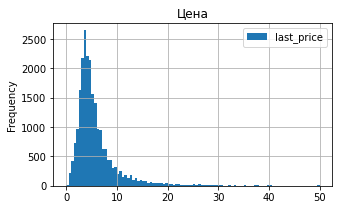

In [52]:
#построим гистограмму
data.plot(y = "last_price", kind="hist", title="Цена", bins=100, range=(0,50), grid=True, figsize=(5,3))

<AxesSubplot:>

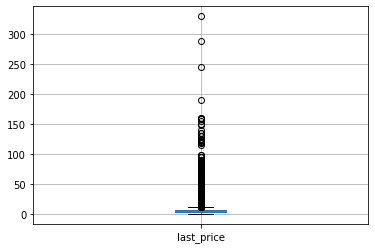

In [53]:
#посторим диаграмму размаха
data.boxplot("last_price")

Нижний «ус» у значения 0, минимальное значение. Верхний заканчивается около 11 — это 1,5 межквартильного размаха, добавленного к 3-му квартилю. Это ориентировочная граница нормального размаха. Всё, что лежит за ней, считается выбросом. Уберем слишком высокие значения(будем считать от 50) и слишком малые значения(до 1)

In [54]:
#оставим только нужный срез
data = data.query("last_price < 50 and last_price > 1") 
#поменяем цены обратно
data["last_price"] = data["last_price"]*1000000
#для проверки выведем общую информацию
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 23162 entries, 0 to 23698
Data columns (total 29 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   total_images          23162 non-null  int64         
 1   last_price            23162 non-null  float64       
 2   total_area            23162 non-null  float64       
 3   first_day_exposition  23162 non-null  datetime64[ns]
 4   rooms                 23162 non-null  int64         
 5   ceiling_height        23162 non-null  float64       
 6   floors_total          23162 non-null  int64         
 7   living_area           23162 non-null  float64       
 8   floor                 23162 non-null  int64         
 9   is_apartment          23162 non-null  bool          
 10  studio                23162 non-null  bool          
 11  open_plan             23162 non-null  bool          
 12  kitchen_area          23162 non-null  float64       
 13  balcony         

/tmp/ipykernel_137/1252149427.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["last_price"] = data["last_price"]*1000000


5) количество комнат

In [55]:
#вывод общей информации по числовым характеристикам выборки
data["rooms"].describe()

count    23162.000000
mean         2.055479
std          1.041551
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         16.000000
Name: rooms, dtype: float64

<AxesSubplot:>

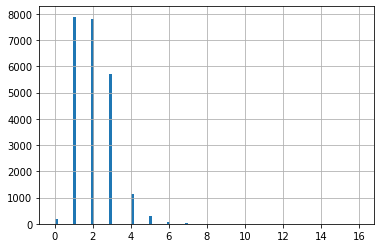

In [56]:
#построим гистограмму
data["rooms"].hist(bins=100, range=(0,16))

<AxesSubplot:>

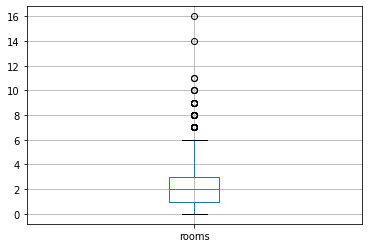

In [57]:
#построим ящик с усами 
data.boxplot("rooms")

Аномальное значения в столбце с количеством комнат-- это отсутствие комнат(значение 0). Такого быть не может, поэтому удалим эти значения. Также по диаграмме размаха видно, что значения больше 7 -- это выбросы. Их также уберем

In [58]:
#выведем уникальные значения до изменений
data["rooms"].unique()

array([ 3,  1,  2,  4,  5,  6,  0, 11,  7,  8, 10,  9, 16, 14])

In [59]:
#создадим переменную, в к-рую запишем условие для нужного среза
row = (data["rooms"] > 0) & (data["rooms"] < 7)
#перезапишем датафрейм
data = data.loc[row]
#для проверки выведем уникальные значения
data["rooms"].unique()

array([3, 1, 2, 4, 5, 6])

6) высота потолков

Выведем общую информацию, сделаем ящик с усами и гистограмму:

In [60]:
#вывод общей информации по числовым характеристикам выборки
data["ceiling_height"].describe()

count    22909.000000
mean         2.720445
std          0.989289
min          1.000000
25%          2.600000
50%          2.650000
75%          2.700000
max        100.000000
Name: ceiling_height, dtype: float64

<AxesSubplot:>

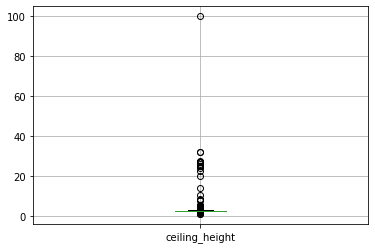

In [61]:
#построим ящик с усами
data.boxplot("ceiling_height")

(0.0, 6.0)

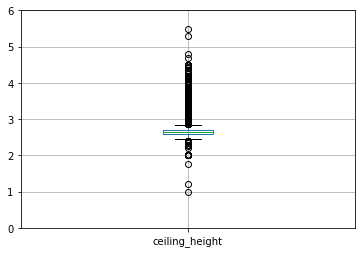

In [62]:
#построим диаграмму размаха
data.boxplot("ceiling_height")
#поменяем маштаб по вертикали
plt.ylim(0, 6)

По диаграмме размаха видно, что значения меньше 2.4 и больше 2.8 - это выбросы. Рассмотрим поподробнее, используя в этот раз гистограмму для оценки частоты каждого значения в наборе данных

<AxesSubplot:>

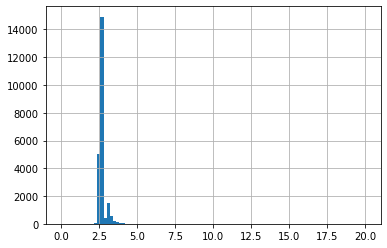

In [63]:
#построим гистограмму
data["ceiling_height"].hist(bins=100, range=(0,20))

Рассмотрим поближе срез с 0 до 6м: 

<AxesSubplot:>

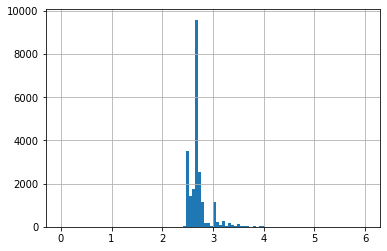

In [64]:
#укажем границы среза 0 и 6
data["ceiling_height"].hist(bins=100, range=(0,6))

<AxesSubplot:>

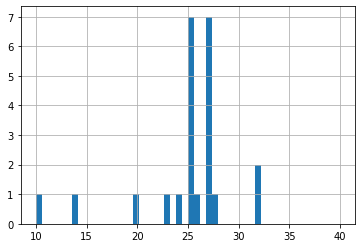

In [65]:
#укажем границы среза 10 и 40
data["ceiling_height"].hist(bins=50, range=(10,40))

Скорее всего значения меньше 2м и больше 6м - это ошибки ввода, которые можно например медианой заменить. Также могла быть ошибка и в записи чисел(может высоты от 20 просто записаны неправильно, нужно перевести в вещественные).

In [66]:
#выведем до изменений уникальные значения
data["ceiling_height"].unique()

array([  2.7 ,   2.65,   3.03,   2.5 ,   2.67,   2.56,   3.05,   2.75,
         2.6 ,   2.9 ,   2.8 ,   2.55,   3.  ,   3.2 ,   2.61,   3.25,
         3.45,   2.77,   2.85,   2.64,   2.57,   4.15,   3.3 ,   2.71,
         4.  ,   2.47,   2.73,   2.84,   3.1 ,   2.34,   3.4 ,   3.5 ,
         3.06,   2.72,   2.54,   2.51,   2.78,   2.76,  25.  ,   2.58,
         3.7 ,   2.52,   2.87,   2.66,   2.59,   2.  ,   2.45,   3.6 ,
         2.92,   3.11,   3.13,   3.8 ,   3.15,   3.55,   3.62,   3.12,
         2.53,   2.74,   2.96,   2.46,   2.79,   2.95,   4.06,   2.94,
         3.54,   3.53,   2.83,   2.4 ,   3.38,   3.01,   3.65,   3.18,
         3.35,   2.3 ,   3.57,   2.48,   2.62,   2.82,   3.98,   2.63,
         3.83,   3.52,   3.95,   3.75,   2.88,   3.67,   3.87,   3.66,
         4.19,   3.24,   4.8 ,   4.5 ,   4.2 ,   3.36,   3.86,  32.  ,
         3.08,   3.68,   3.07,   3.37,   3.09,   8.  ,   3.16,   3.26,
         3.34,   2.81,   3.44,   2.97,   4.37,   2.68,   3.9 ,   3.22,
      

Можно заметить, что указана высота потолков от 25 м до 32 м. Логично предположить, что на самом деле это вещественные значения: от 2.5 м до 3.2 м. Это можно исправить и сохранить данные, например, с помощью update

In [67]:
#поменяем высоту от 20 до 36 на вещественные значения: от 2.0 м до 3.6 м
data.update(data[(data['ceiling_height'] >= 20) & (data['ceiling_height'] <= 36)]['ceiling_height']/10)
#выведем для проверки уникальные значения
data['ceiling_height'].unique()

array([  2.7 ,   2.65,   3.03,   2.5 ,   2.67,   2.56,   3.05,   2.75,
         2.6 ,   2.9 ,   2.8 ,   2.55,   3.  ,   3.2 ,   2.61,   3.25,
         3.45,   2.77,   2.85,   2.64,   2.57,   4.15,   3.3 ,   2.71,
         4.  ,   2.47,   2.73,   2.84,   3.1 ,   2.34,   3.4 ,   3.5 ,
         3.06,   2.72,   2.54,   2.51,   2.78,   2.76,   2.58,   3.7 ,
         2.52,   2.87,   2.66,   2.59,   2.  ,   2.45,   3.6 ,   2.92,
         3.11,   3.13,   3.8 ,   3.15,   3.55,   3.62,   3.12,   2.53,
         2.74,   2.96,   2.46,   2.79,   2.95,   4.06,   2.94,   3.54,
         3.53,   2.83,   2.4 ,   3.38,   3.01,   3.65,   3.18,   3.35,
         2.3 ,   3.57,   2.48,   2.62,   2.82,   3.98,   2.63,   3.83,
         3.52,   3.95,   3.75,   2.88,   3.67,   3.87,   3.66,   4.19,
         3.24,   4.8 ,   4.5 ,   4.2 ,   3.36,   3.86,   3.08,   3.68,
         3.07,   3.37,   3.09,   8.  ,   3.16,   3.26,   3.34,   2.81,
         3.44,   2.97,   4.37,   2.68,   3.9 ,   3.22,   3.27,   4.1 ,
      

7) тип этажа квартиры

In [68]:
#вывод общей информации по числовым характеристикам выборки
data["floor_type"].describe()

count      22909
unique         3
top       другой
freq       16931
Name: floor_type, dtype: object

<AxesSubplot:>

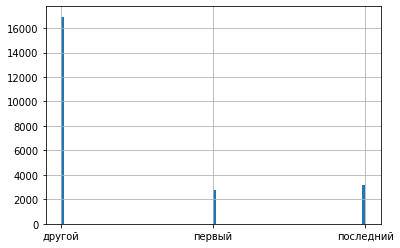

In [69]:
#пострим гистограмму
data["floor_type"].hist(bins=100)

По количеству оказалось больше всего данных группы "другое". Это нормально, ведь многие люди предпочитают брать квартиры, начиная со второго этажа. Есть спрос на эту группу, поэтому этих предложений больше.

8) общее количество этажей в доме

In [70]:
#вывод общей информации по числовым характеристикам выборки
data["floors_total"].describe()

count    22909.000000
mean        10.731372
std          6.576048
min          1.000000
25%          5.000000
50%          9.000000
75%         16.000000
max         60.000000
Name: floors_total, dtype: float64

<AxesSubplot:>

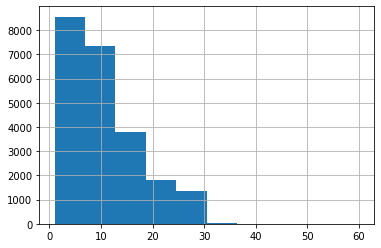

In [71]:
#построим гистограмму
data["floors_total"].hist(bins=10)

<AxesSubplot:>

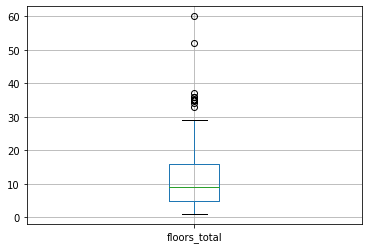

In [72]:
#построим диаграмму размаха
data.boxplot("floors_total")

Начиная со значения 30 у нас идут выбросы. Избавимся от части

In [73]:
#оставим нужный срез
data = data.loc[(data["floors_total"] < 50)|(data["floors_total"].isna())]

9) расстояние до центра города в метрах

In [74]:
#вывод общей информации по числовым характеристикам выборки
data["cityCenters_nearest"].describe()

count    17729.000000
mean     14302.509673
std       8611.179864
min        181.000000
25%       9436.000000
50%      13151.000000
75%      16318.000000
max      65968.000000
Name: cityCenters_nearest, dtype: float64

<AxesSubplot:>

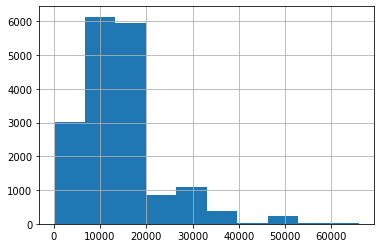

In [75]:
#пострим гистограмму
data["cityCenters_nearest"].hist(bins=10)

<AxesSubplot:>

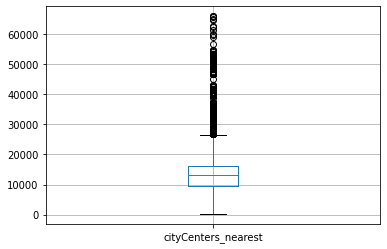

In [76]:
#построим диаграмму размаха
data.boxplot("cityCenters_nearest")

Верхний ус заканчивается около 20000 — это 1,5 межквартильного размаха, добавленного к 3-му квартилю. Это ориентировочная граница нормального размаха. Всё, что лежит за ней, считается выбросом. Чтобы сильно не сокращать данные, уберем выбросы от 50000м. 

In [77]:
#оставим только нужный срез данных 
data = data.loc[(data['cityCenters_nearest'] < 50000)|(data['cityCenters_nearest'].isna())]
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 22721 entries, 0 to 23698
Data columns (total 29 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   total_images          22721 non-null  int64         
 1   last_price            22721 non-null  float64       
 2   total_area            22721 non-null  float64       
 3   first_day_exposition  22721 non-null  datetime64[ns]
 4   rooms                 22721 non-null  int64         
 5   ceiling_height        22721 non-null  float64       
 6   floors_total          22721 non-null  int64         
 7   living_area           22721 non-null  float64       
 8   floor                 22721 non-null  int64         
 9   is_apartment          22721 non-null  bool          
 10  studio                22721 non-null  bool          
 11  open_plan             22721 non-null  bool          
 12  kitchen_area          22721 non-null  float64       
 13  balcony         

10) расстояние до ближайшего парка

In [78]:
#вывод общей информации по числовым характеристикам выборки
data["parks_nearest"].describe()

count    7767.000000
mean      493.927643
std       342.701294
min         1.000000
25%       290.000000
50%       456.000000
75%       614.000000
max      3190.000000
Name: parks_nearest, dtype: float64

<AxesSubplot:>

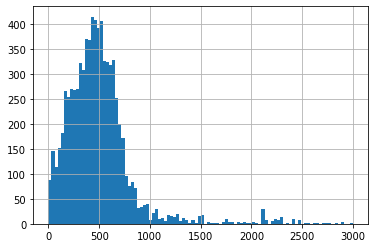

In [79]:
#построим гистограмму
data["parks_nearest"].hist(bins=100, range=(0,3000))

Аномальное значение -- растояние до парка в 1 м. Это странно. Оно означает, что либо парка нет рядом, либо это ошибка. Уберем  значения меньше 100 метров. Также ограничимся расстоянием максимум до 3000

In [80]:
#оставим только нужный срез
data = data.loc[(data['parks_nearest'] > 100)&(data['parks_nearest'] < 3000)|(data['parks_nearest'].isna())]

In [81]:
#для проверки количества строк выведем общую информацию
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 22320 entries, 0 to 23698
Data columns (total 29 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   total_images          22320 non-null  int64         
 1   last_price            22320 non-null  float64       
 2   total_area            22320 non-null  float64       
 3   first_day_exposition  22320 non-null  datetime64[ns]
 4   rooms                 22320 non-null  int64         
 5   ceiling_height        22320 non-null  float64       
 6   floors_total          22320 non-null  int64         
 7   living_area           22320 non-null  float64       
 8   floor                 22320 non-null  int64         
 9   is_apartment          22320 non-null  bool          
 10  studio                22320 non-null  bool          
 11  open_plan             22320 non-null  bool          
 12  kitchen_area          22320 non-null  float64       
 13  balcony         

ВЫВОД: Мы рассмотрели данные, нашли аномалии, сделав для них гистограмму, диаграмму размаха и общую информацию по каждому интересуещему столбцу. Аномалии и выбросы могли возникнуть вследвие как технических ошибок(ошибки в алгоритмах, считающих расстояние, выгрузка не всех данных), так и человеческих(указали неверные данные или вообще не указали ничего). Избавившись от аномалий и выбросов, мы смогли более эффективно очистить данные и теперь можно перейти к поиску решения для нашей задачи: установить параметры, влияющие на цену объектов

Сравним изначальное количество данных с результатом после фильтрации

In [82]:
data_orig.shape

(23565, 29)

In [83]:
data.shape

(22320, 29)

In [84]:
#найдем сколько процентов данных сохранилось
percent_remaining  = data.shape[0] * 100 / data_orig.shape[0]
percent_remaining

94.71674092934437

Отлично. В результате очистки данных от выбросов и аномалий нам удалось сохранить более 90% исходных данных.

**Вернемся к столбцу days_exposition. Изучим скорость продажи квартир**

<AxesSubplot:>

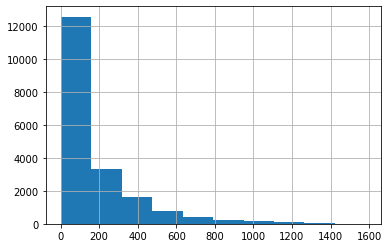

In [85]:
#построим гистограмму:
data['days_exposition'].hist()

<AxesSubplot:>

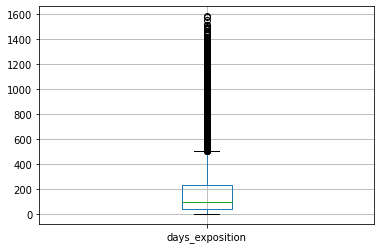

In [86]:
#построим диаграмму размаха
data.boxplot("days_exposition")

Можно увидеть, что большая часть значений лежит в диапазоне до 200 дней, что выглядит правдоподобно. Но при этом 1-й квартиль лежит на уровне менее 50 дней.

In [87]:
#посмотрим на среднее и медиану через числовое описание данных для колонки
data['days_exposition'].describe()

count    19345.000000
mean       179.842698
std        218.679339
min          2.000000
25%         45.000000
50%         95.000000
75%        230.000000
max       1580.000000
Name: days_exposition, dtype: float64

- Среднее ~ 180
- Медиана - 95

Для начала найдем населенный пункт с самыми большими значениями в столбце days_exposition

In [88]:
#отметим нужный нам срез
days_ex_loc_name = data.loc[:,['locality_name', 'days_exposition']]
#отсортируем данные
print(days_ex_loc_name.sort_values(by='days_exposition',ascending=False).head(10))

                 locality_name  days_exposition
18843  поселок Новое Девяткино           1580.0
1109           Санкт-Петербург           1572.0
9553           Санкт-Петербург           1553.0
1885           Санкт-Петербург           1513.0
6691                    Пушкин           1512.0
20969          Санкт-Петербург           1512.0
14093          Санкт-Петербург           1497.0
15313               Сестрорецк           1489.0
19123                 Павловск           1485.0
11955          Санкт-Петербург           1484.0


Большинство долгих по времени продаж в Санкт-Петербурге. Нужно проверить, как  распределение времени в этом нас.пункте соотносится с распределением времени продаж в целом?

In [89]:
#оставим только срез с нужным нас.пунктом
one_ex = data.query('locality_name == "Санкт-Петербург"')
print(len(one_ex))

14981


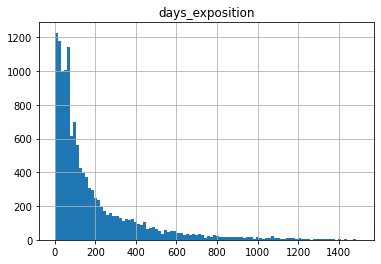

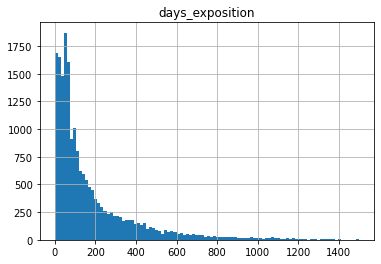

In [90]:
#построим гистограммы
one_ex.hist("days_exposition",bins=100, range=(0,1500))
plt.show()
data.hist("days_exposition",bins=100, range=(0,1500))
plt.show()

Гистограммы среза one_ex и всего набора данных по всем нас.пунктам внешне похожи — имеют по три пика: около нулевого времени продажи, около 70 дней и 100 дней. Но если в первом случае самый большой пик у 0, то во втором это значение, близкое к 60-70

Найдем слишком долгие продажи:
Продажи продолжительностью 800 дней — уже редки. Дольше 1200 дней почти нет. А на участке более 1400 дней гистограмма сливается с нулём (это не значит, что там ровно 0, но такой продолжительности мало).

Теперь рассмотрим аномально быстрые продажи: это 0-1 день. Значение 0 вероятнее всего означает отсутсвие продажи

ВЫВОД: Продажа обычно занимает в среднем до 100 дней, если значения равны 0-1, то это должно заставить задуматься: скорее всего это не продажи, а сразу снятые объявления о продаже. Продажи дольше  270 дней(по q3 и 1,5 межквартильного размаха) уже можно считать долгими.
Быстрые можно взять до 1 квартиля

**Определим факторы, которые больше всего влияют на общую (полную) стоимость объекта**

Изучим, зависит ли цена от:
- общей площади;
- жилой площади;
- площади кухни;
- количества комнат;
- этажа, на котором расположена квартира (первый, последний, другой);
- даты размещения (день недели, месяц, год).

Посмотрим на зависимость цены от площадей по отдельности: от общей, от жилой и от площади кухни

In [91]:
print(data['total_area'].corr(data['last_price']))

0.779067328990299


Общая площадь очень сильно коррелирует с ценой(коэффицент Пирсона равен ~0.77, что говорит о наличии сильной связи между ними)

In [92]:
print(data['kitchen_area'].corr(data['last_price']))

0.6120985017598689


Также и с площадью кухни: доволньно высокая связь(коэффицент Пирсона равен 0.61)

In [93]:
print(data['living_area'].corr(data['last_price']))

0.6820356034100383


У жилой площади связь с ценой чуть выше, учитывая насколько сильно они коррелируют(коэффицент равен 0.68)

In [94]:
#сделаем сводную таблицу для цены и этих трех параметров
data.pivot_table(index=["kitchen_area",'total_area','living_area'], values='last_price').sort_values(by="last_price", ascending = True)

,,,last_price
kitchen_area,total_area,living_area,
6.0,32.2,17.500000,1010000.0
8.6,47.6,27.200000,1020000.0
6.0,29.0,16.383178,1030000.0
6.1,30.4,17.500000,1050000.0
10.0,58.0,34.000000,1050000.0
...,...,...,...
9.7,125.0,73.900000,49000000.0
50.0,119.0,47.000000,49500000.0
28.0,214.0,133.000000,49798000.0


Можно заметить как с увеличением площади повышается и цена

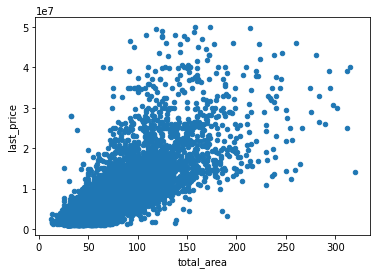

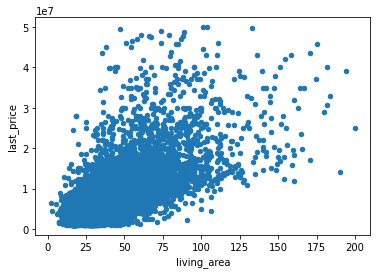

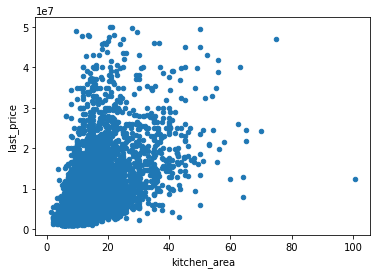

In [95]:
#построим графики
data.plot(x="total_area", y='last_price', kind='scatter')
plt.show()
data.plot(x="living_area", y='last_price', kind='scatter')
plt.show()
data.plot(x="kitchen_area", y='last_price', kind='scatter')
plt.show()

На графике можно увидеть взаимосвязь между каждыми двумя величинами. А также понять, какие данные типичны, а какие — аномальны. 

Далее посмотрим на зависимость цены от количества комнат:

In [96]:
print(data['rooms'].corr(data['last_price']))

0.48277582190179985


Связь тоже довольно высокая. Посмотрим по сводной таблице

In [97]:
#сделаем сводную таблицу по зависимости цены от кол-ва комнат
data.pivot_table(index="rooms", values='last_price', aggfunc="median").sort_values(by="last_price", ascending = True)

,last_price
rooms,
1,3600000.0
2,4800000.0
3,6200000.0
4,8860000.0
5,13000000.0
6,16650000.0


Благодаря сводной таблице и корреляции можем заметить, что с увеличением комнат увеличивается и стоимость. 

Попробуем сделать график:

<AxesSubplot:title={'center':'Зависимость цены от кол-ва комнат'}, xlabel='rooms', ylabel='last_price'>

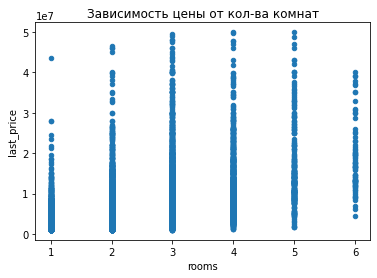

In [98]:
#сделаем график
data.plot(x="rooms", y='last_price', title = "Зависимость цены от кол-ва комнат", kind='scatter')

Для визуализации тут подойдет столбчатая диаграмма

<AxesSubplot:xlabel='rooms', ylabel='last_price'>

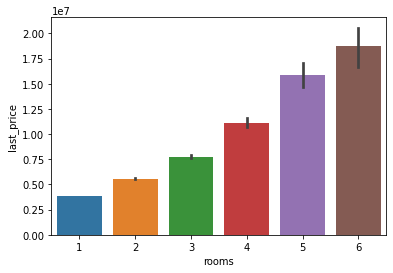

In [99]:
#построим столбчатую диаграмму
seaborn.barplot(x=data['rooms'], y=data['last_price'])

Здесь более наглядно видно, что с увеличением количества комнат повышается и цена

Теперь посмотрим на связь типа этажа с ценой:

In [100]:
#построим сводную таблицу
data.pivot_table(index="floor_type", values='last_price', aggfunc="median")

,last_price
floor_type,
другой,4850000.0
первый,3950000.0
последний,4300000.0


<AxesSubplot:xlabel='floor_type', ylabel='last_price'>

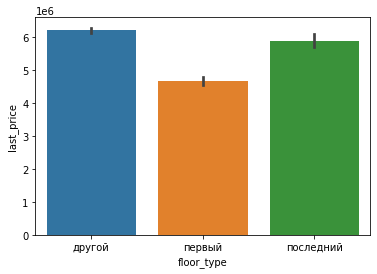

In [101]:
#построим столбчатую диаграмму
seaborn.barplot(x=data['floor_type'], y=data['last_price'])

По диаграмме видно, что первые и последние этажи по цене ниже, чем другие. Это можно объяснить тем, что они меньше пользуются спросом:низкую цену на квартиры на первом и последнем этажах можно аргументировать плохими условиями - шум от улиц и моторов лифта, охлаждаемость помещения зимой. Также многие боятся или им дискомфортно находится на первом этаже, так как в окна квартиры на данном этаже с улицы легко могут смотреть прохожие и выше вероятность, что кто-то вломится, а насчет последнего этажа -- долго ждать лифт, а по лестнице трудно подниматься(особенно если это не пятиэтажный дом)

Рассмотрим по дате размещения (день недели, месяц, год):

<AxesSubplot:xlabel='weekday', ylabel='last_price'>

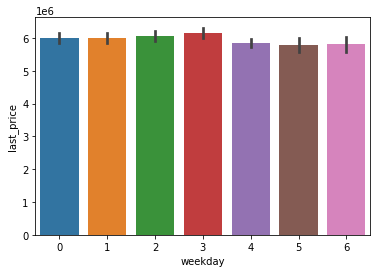

In [102]:
#построим столбчатую диаграмму
seaborn.barplot(x=data['weekday'], y=data['last_price'])

<AxesSubplot:xlabel='month_of_publication', ylabel='last_price'>

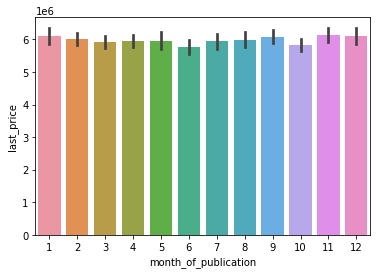

In [103]:
#построим столбчатую диаграмму
seaborn.barplot(x=data['month_of_publication'], y=data['last_price'])

<AxesSubplot:xlabel='year_of_publication', ylabel='last_price'>

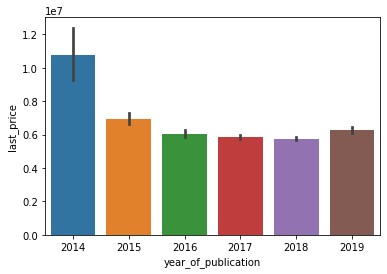

In [104]:
#построим столбчатую диаграмму
seaborn.barplot(x=data['year_of_publication'], y=data['last_price'])

ВЫВОД: По дням недели и по месяцам зависимость не наблюдается, а вот с годами есть взаимосвязь: в 2014 цена была выше, чем в другие годы

**построим сводную таблицу с количеством объявлений и средней ценой квадратного метра для 10 населённых пунктов с наибольшим числом объявлений:**

In [105]:
#построим сводную таблицу
data_local = data.pivot_table(index="locality_name", values=['price_sq_meter',"days_exposition"], aggfunc=["mean", "count"])
#переименуем столбцы
data_local.columns=['mean_days','mean_price_metr','count_days_ex','count_price_metr']
#удалим лишние столбцы
data_local = data_local.loc[:,data_local.columns != 'mean_days']
data_local = data_local.loc[:,data_local.columns != 'count_price_metr']

In [106]:
#отсортируем данные и выведем первые 10 стро
data_local_new = data_local.sort_values(by="count_days_ex", ascending = False).head(10)
data_local_new

,mean_price_metr,count_days_ex
locality_name,,
Санкт-Петербург,111966.901406,13009
поселок Мурино,85029.524273,521
поселок Шушары,78277.935520,403
Всеволожск,68683.728439,334
поселок Парголово,90480.153606,296
Колпино,75161.956427,296
Пушкин,103508.328230,289
поселок Кудрово,92297.218847,283
Гатчина,68935.194838,267


Выделим населённые пункты с самой высокой и низкой стоимостью квадратного метра:

In [107]:
data_local_new.sort_values(by="mean_price_metr", ascending = False).head(1)

,mean_price_metr,count_days_ex
locality_name,,
Санкт-Петербург,111966.901406,13009


In [108]:
data_local_new.sort_values(by="mean_price_metr", ascending = False).tail(1)

,mean_price_metr,count_days_ex
locality_name,,
Выборг,58685.669032,205


ВЫВОД: населённый пункт с самой высокой стоимостью квадратного метра и с самым большим количеством обьявлений - Санкт-Петербург, а с самой низкой стоимостью квадратного метра среди населенных пунктов с наибольшим числом объявлений - Выборг

Посмотрим, как стоимость объектов зависит от расстояния до центра города в Санкт-Петербурге

In [109]:
data['last_price'] = data["last_price"]*1000000
data_st_piter = data.query("locality_name == 'Санкт-Петербург'")
data_st_piter["locality_name"].head()

0     Санкт-Петербург
4     Санкт-Петербург
7     Санкт-Петербург
9     Санкт-Петербург
10    Санкт-Петербург
Name: locality_name, dtype: object

In [110]:
data_st_piter_new = data_st_piter.pivot_table(index="center_km_nearest", values='last_price', aggfunc="mean")
data_st_piter_new

,last_price
center_km_nearest,
0.0,1.828408e+13
1.0,1.244747e+13
2.0,1.173165e+13
3.0,1.011120e+13
4.0,1.094882e+13
5.0,1.143436e+13
6.0,1.181612e+13
7.0,1.101392e+13
8.0,9.211681e+12


<AxesSubplot:xlabel='center_km_nearest'>

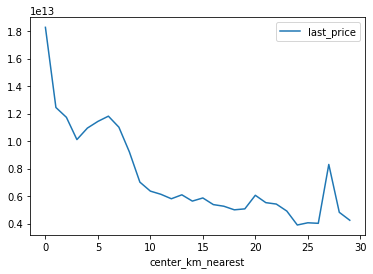

In [111]:
data_st_piter_new.plot()

На графике после 7 км заметно, что цена меняется. Это возможный центр города. C удалением от центра стоимость квартиры падает. Следовательно, чем ближе к центру Санкт-Петербурга, тем выше стоимость квартиры. Но присутствуют дополнительные пики у значений 7км и 27км. Возможно там оказывают влияние на стоимость и другие факторы, выделенные ранее(площадь квартиры, количество комнат, тип этажа) 

### Общий вывод

- Во многих столбцах были найдены аномалии: количество комнат было исправлено, в соответствии с логикой слишком большое количество комнат, также были отрегулированы высота потолков, цена.
- Были изученны: все виды площадей, цена, число комнат, высота потолков. Сделаны диаграммы размаха и гистограммы для каждого параметра.
- Также были добавлены параметры для дополнительного использования: цена одного кв.м, день недели, месяц, год публикации, типы этажей, переведено расстояние из метров в км
- Продажа обычно занимает в среднем до 100 дней, если значения равны 0-1, то это должно заставить задуматься: скорее всего это не продажи, а сразу снятые объявления о продаже. Продажи дольше 270 дней уже можно считать долгими
- Определили факторы, которые больше всего влияют на общую (полную) стоимость объекта. Была обнаружена линейная зависимость (чем больше один признак, тем больше другой) цены от разных параметров: более заментая связь с расстоянием до центра города(чем ближе к центру, тем выше стоимость квартиры), также с общей площадью(можно заметить как с увеличением площади повышается и цена) и количеством комнат( с увеличением количества комнат цена также увеличивается)
- Если учитывать эти факторы при прогнозе цены, это позволит построить автоматизированную систему: она отследит аномалии и мошенническую деятельность.  